In [15]:
library(gamlss)
library(readxl)
library(writexl)
library(psych)
library(tidyr)
library(dplyr)

In [13]:
male <- read_excel("male_data.xlsx")
head(male)

ks,tl,umur,sex,tb,bb,bf,bmi
<chr>,<dttm>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
SM71,2013-06-24,12.3,M,143.0,39.5,13.4,19.3
SM72,2012-10-01,13.0,M,147.5,37.5,11.1,17.2
SM73,2012-12-22,12.8,M,158.0,41.8,8.1,16.7
SM74,2013-02-14,12.6,M,160.0,64.7,22.0,25.3
SM75,2013-04-30,12.4,M,145.0,45.3,0.0,21.5
SM76,2012-10-28,12.9,M,166.5,69.5,27.8,25.1


### Pemodelan Tinggi Badan Terhadap Umur 

In [5]:
tb_bcpe <- gamlss(
    tb ~ pb(umur),
    sigma.formula = ~ pb(umur),
    nu.formula = ~pb(umur),
    tau.formula = ~1, 
    family = BCPE, 
    data = male, 
    method = mixed(2, 40))

GAMLSS-RS iteration 1: Global Deviance = 5651.713 
GAMLSS-RS iteration 2: Global Deviance = 5625.549 
GAMLSS-CG iteration 1: Global Deviance = 5624.18 
GAMLSS-CG iteration 2: Global Deviance = 5623.936 
GAMLSS-CG iteration 3: Global Deviance = 5623.887 
GAMLSS-CG iteration 4: Global Deviance = 5623.872 
GAMLSS-CG iteration 5: Global Deviance = 5623.866 
GAMLSS-CG iteration 6: Global Deviance = 5623.864 
GAMLSS-CG iteration 7: Global Deviance = 5623.863 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.45 to 12.95,-0.511,-1.068,1.255,0.462,1.789,93
12.95 to 13.35,1.018,0.443,-1.093,-1.190,2.613,76
13.35 to 14.05,-0.032,1.108,-0.876,-1.710,3.690,94
14.05 to 14.55,-0.853,1.037,0.429,-0.984,1.153,73
14.55 to 15.25,0.109,-1.247,-0.374,-0.217,0.187,79
15.25 to 15.85,0.541,0.263,-0.012,0.199,0.040,88
15.85 to 16.35,-0.456,-0.317,0.703,1.377,2.389,94
16.35 to 16.95,0.743,-0.949,-0.206,0.570,0.368,70
16.95 to 17.55,-0.413,0.267,0.452,0.790,0.829,83
17.55 to 19.85,-0.064,0.357,-0.148,0.156,0.046,77


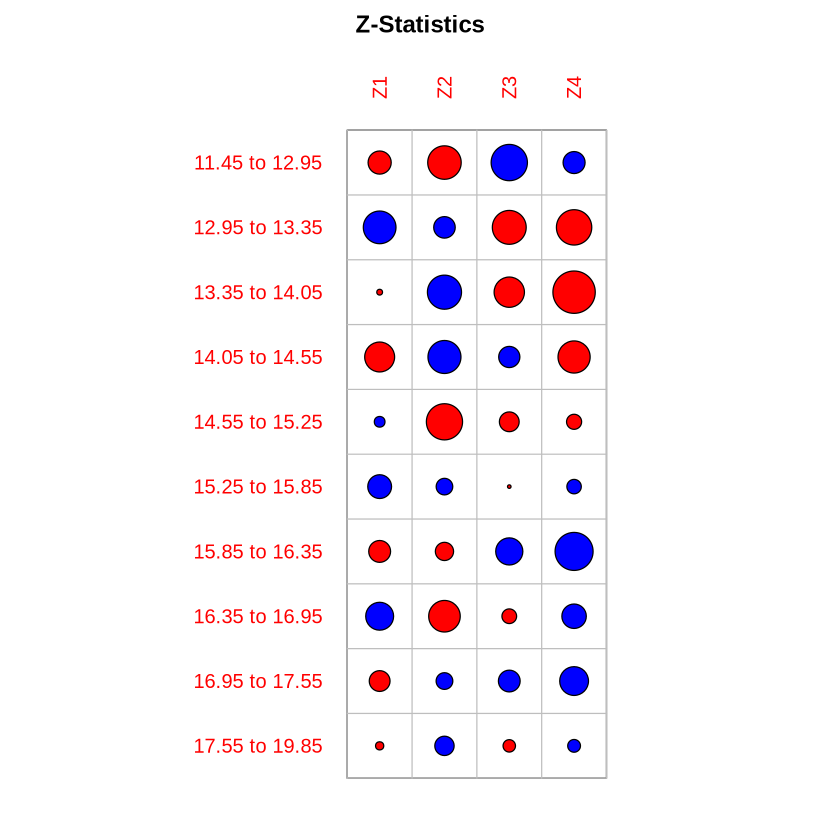

In [6]:
round(Q.stats(tb_bcpe, male$umur), 3)

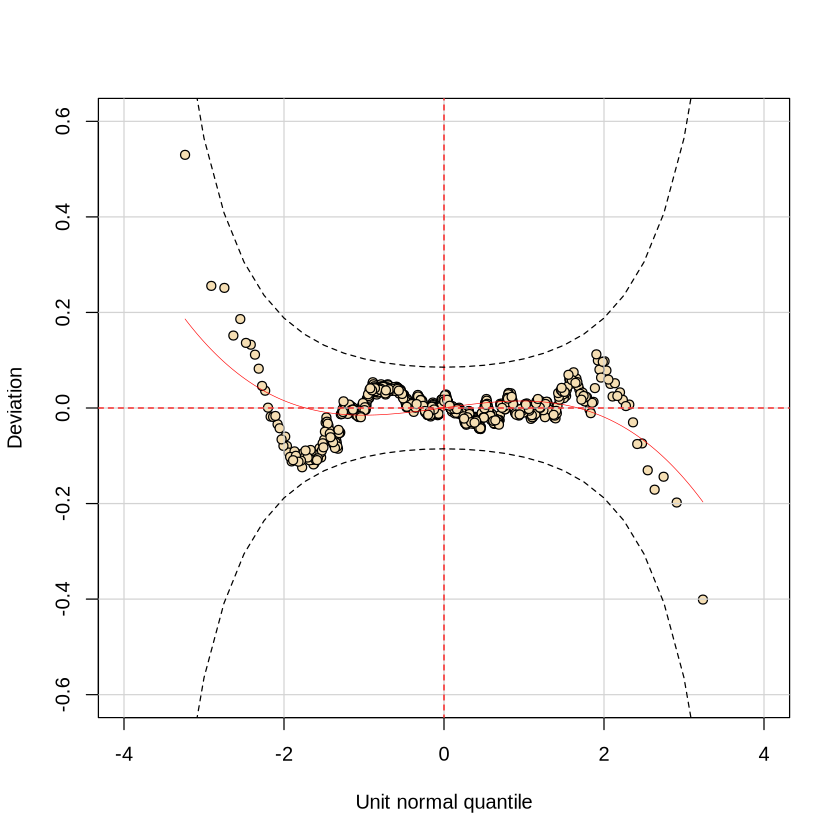

In [7]:
wp(tb_bcpe, ylim.all=0.6)

% of cases below  0.4 centile is  0.241838 
% of cases below  2 centile is  2.297461 
% of cases below  10 centile is  10.15719 
% of cases below  25 centile is  23.5792 
% of cases below  50 centile is  49.45586 
% of cases below  75 centile is  75.69528 
% of cases below  90 centile is  89.96372 
% of cases below  98 centile is  97.58162 
% of cases below  99.6 centile is  99.75816 


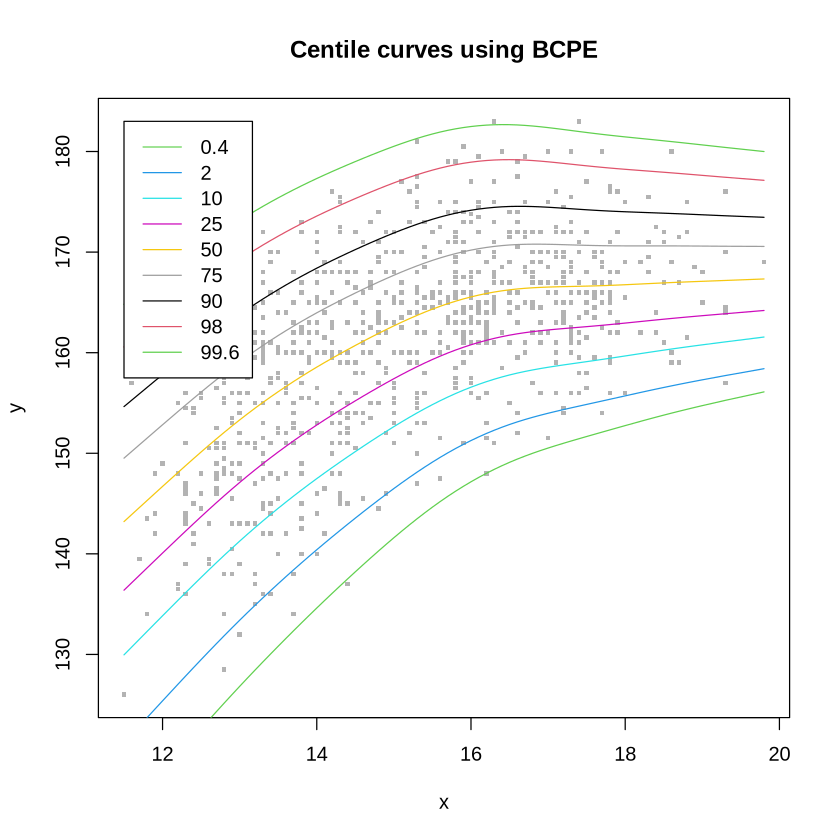

In [8]:
centiles(tb_bcpe)

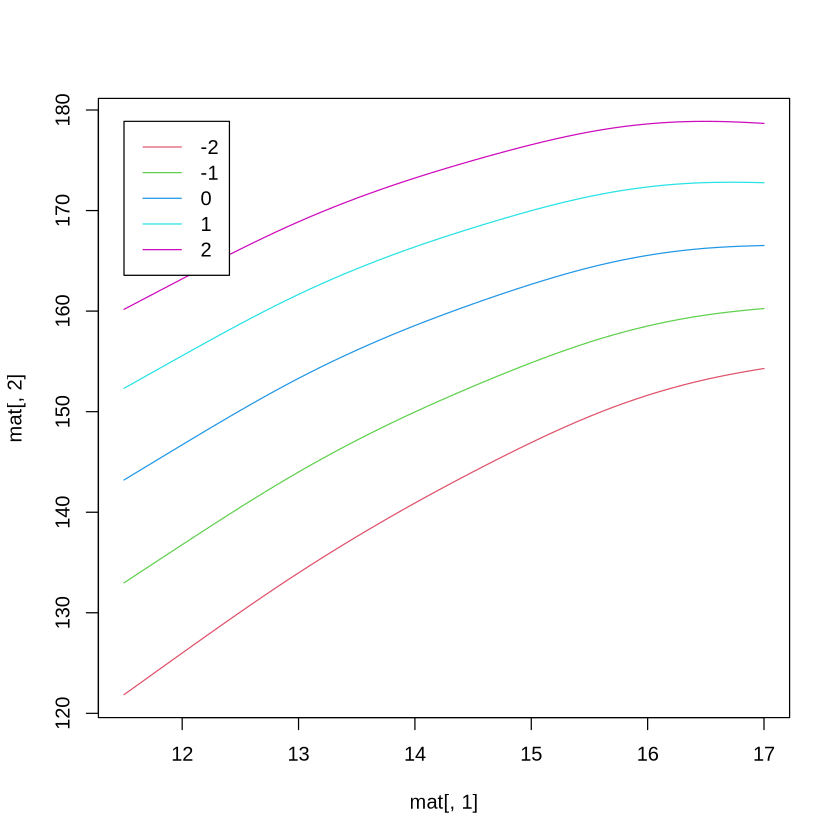

In [14]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=17, by=0.1)

# prediksi z-score
zscore_tb_male <- centiles.pred(
    obj=tb_bcpe,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [17]:
tb_df_male <- as.data.frame(zscore_tb_male)
colnames(tb_df_male) <- c("umur", paste0("Z", Z_scores))

tb_df_male_long  <- tb_df_male %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source = "local_male_tb")

headTail(tb_df_male_long, top = 5, bottom = 5)

umur,Z,Value,Source
<chr>,<chr>,<chr>,<chr>
11.5,Z-2,121.86,local_male_tb
11.5,Z-1,132.98,local_male_tb
11.5,Z0,143.21,local_male_tb
11.5,Z1,152.32,local_male_tb
11.5,Z2,160.18,local_male_tb
...,NA,...,NA
17,Z-2,154.29,local_male_tb
17,Z-1,160.26,local_male_tb
17,Z0,166.52,local_male_tb


In [18]:
write_xlsx(tb_df_male_long, "zscore_tb_male.xlsx")

#### Menggabungkan Data Z-Score Tinggi Badan dengan Data WHO

In [22]:
who_male <- read_excel("raw_data/hfa-boys-z-who-2007-exp.xlsx") 

# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_tb <- who_male %>%
     select(Month, SD2neg, SD1neg, SD0, SD2, SD1) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_tb_long <- who_tb %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_tb_male")

head(who_tb_long) #cek hasil

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,101.082,WHO_tb_male
61,Z-1,105.673,WHO_tb_male
61,Z0,110.265,WHO_tb_male
61,Z2,119.448,WHO_tb_male
61,Z1,114.856,WHO_tb_male
62,Z-2,101.555,WHO_tb_male


In [23]:
who_tb_long$umur<-who_tb_long$umur/12 # mengubah satuan umur dari bulan ke tahun
who_tb_long$umur <- round(who_tb_long$umur, 2) # dua decimal
head(who_tb_long) # cek data

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
5.08,Z-2,101.082,WHO_tb_male
5.08,Z-1,105.673,WHO_tb_male
5.08,Z0,110.265,WHO_tb_male
5.08,Z2,119.448,WHO_tb_male
5.08,Z1,114.856,WHO_tb_male
5.17,Z-2,101.555,WHO_tb_male


In [24]:
# filter data dari usia 11.5 - 19 tahun
who_male_tb1219 <- who_tb_long %>%
  filter(umur >= 11.5, umur <= 19)

who_male_tb1219$umur <- round(who_male_tb1219$umur, 2)
head(who_male_tb1219) # cek hasil

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.50,Z-2,132.173,WHO_tb_male
11.50,Z-1,139.081,WHO_tb_male
11.50,Z0,145.989,WHO_tb_male
11.50,Z2,159.806,WHO_tb_male
11.50,Z1,152.897,WHO_tb_male
11.58,Z-2,132.612,WHO_tb_male


In [25]:
# menggabungkan data penelitian dan data WHO
tb_male_zscore_gabungan1219 <- bind_rows(tb_df_male_long, who_male_tb1219)
headTail(tb_male_zscore_gabungan1219, top = 5, bottom = 5) # cek hasil

umur,Z,Value,Source
<chr>,<chr>,<chr>,<chr>
11.5,Z-2,121.86,local_male_tb
11.5,Z-1,132.98,local_male_tb
11.5,Z0,143.21,local_male_tb
11.5,Z1,152.32,local_male_tb
11.5,Z2,160.18,local_male_tb
...,NA,...,NA
19,Z-2,161.95,WHO_tb_male
19,Z-1,169.24,WHO_tb_male
19,Z0,176.54,WHO_tb_male


In [26]:
write_xlsx(tb_male_zscore_gabungan1219, "clean_data/male_tb_gabungan1219.xlsx") # eksport output

### Index Massa Tubuh

In [27]:
bmi_male <- gamlss(formula = bmi ~ pb(umur), 
                   sigma.formula = ~1,
                   nu.formula = ~pb(umur), 
                   tau.formula = ~1, 
                   family = BCPE,
                   data = male) 

GAMLSS-RS iteration 1: Global Deviance = 4655.517 
GAMLSS-RS iteration 2: Global Deviance = 4572.262 
GAMLSS-RS iteration 3: Global Deviance = 4552.398 
GAMLSS-RS iteration 4: Global Deviance = 4547.169 
GAMLSS-RS iteration 5: Global Deviance = 4546.039 
GAMLSS-RS iteration 6: Global Deviance = 4545.813 
GAMLSS-RS iteration 7: Global Deviance = 4545.732 
GAMLSS-RS iteration 8: Global Deviance = 4545.714 
GAMLSS-RS iteration 9: Global Deviance = 4545.71 
GAMLSS-RS iteration 10: Global Deviance = 4545.709 
GAMLSS-RS iteration 11: Global Deviance = 4545.708 


,Z1,Z2,Z3,Z4,AgostinoK2,N
11.45 to 12.95,0.592,0.950,-0.139,-2.341,5.501,93
12.95 to 13.35,-0.467,1.014,-1.949,2.036,7.944,76
13.35 to 14.05,-1.203,0.831,1.632,-0.733,3.200,94
14.05 to 14.55,-1.399,-1.926,0.304,-0.310,0.189,73
14.55 to 15.25,1.189,-1.252,1.709,-0.163,2.946,79
15.25 to 15.85,0.261,-1.844,-0.093,-1.027,1.063,88
15.85 to 16.35,-0.850,0.238,0.688,1.230,1.986,94
16.35 to 16.95,0.259,0.226,0.161,0.791,0.651,70
16.95 to 17.55,1.345,1.080,-1.404,0.440,2.165,83
17.55 to 19.85,-0.720,-0.415,0.334,-1.337,1.900,77


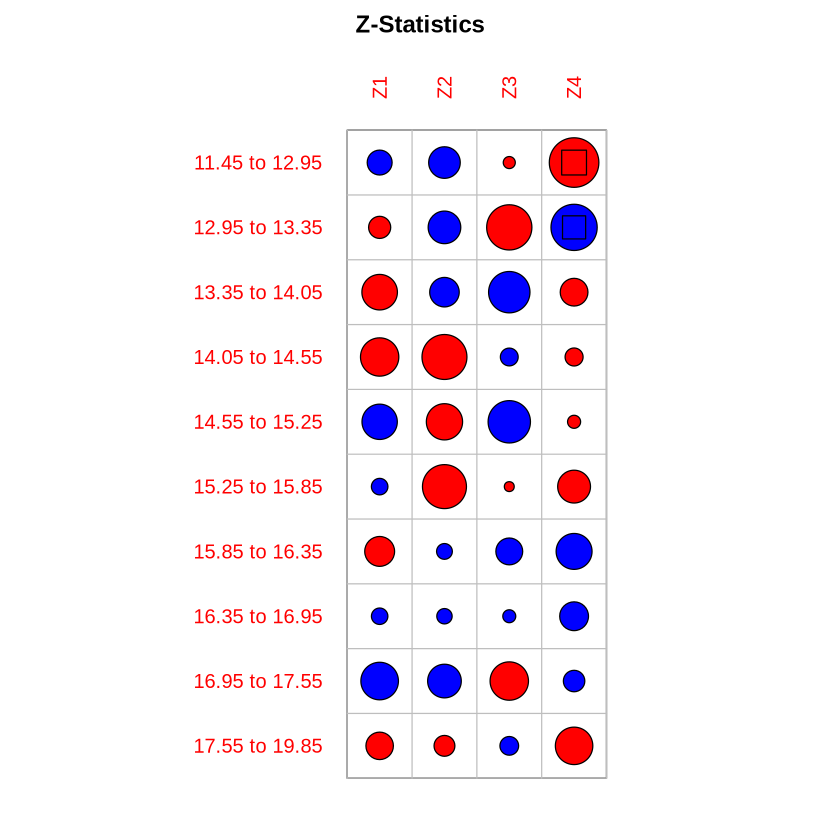

In [28]:
round(Q.stats(bmi_male, male$umur), 3)

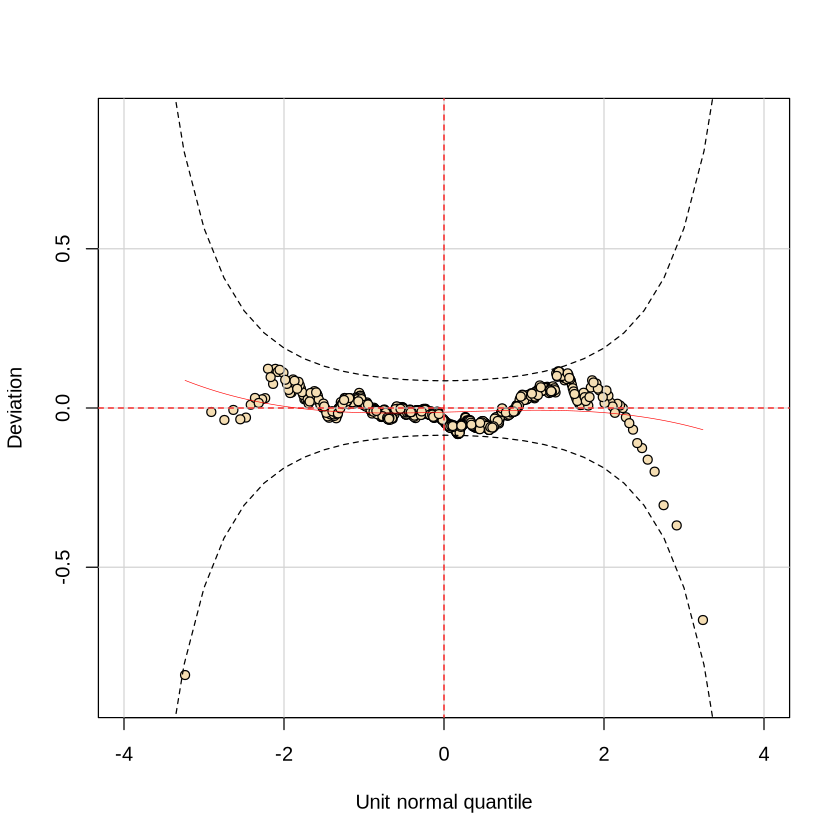

In [29]:
wp(bmi_male, ylim.all=0.9)

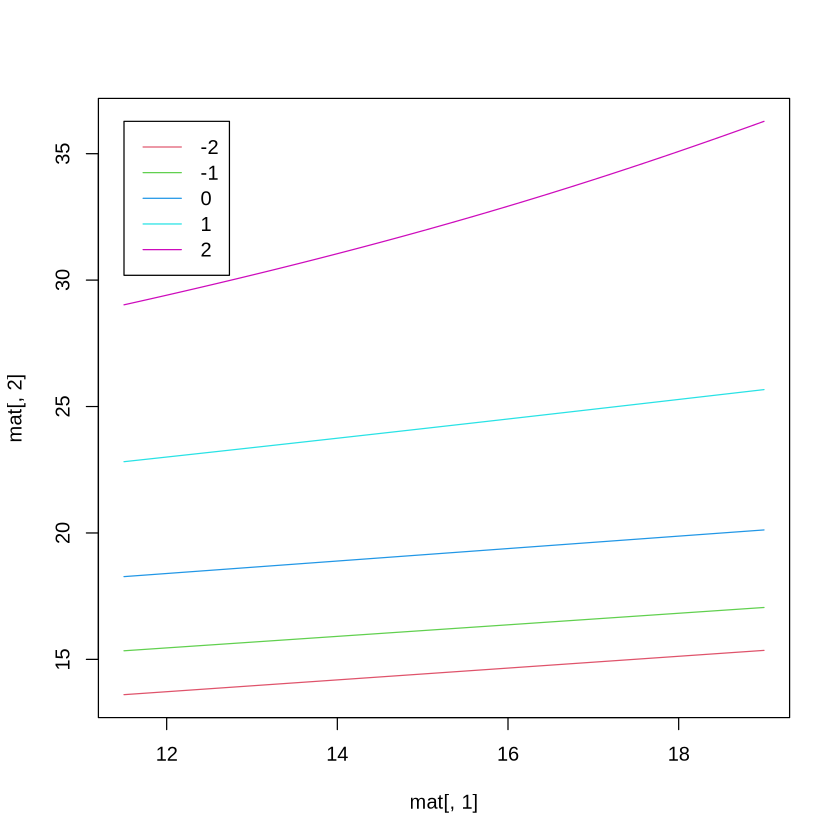

In [30]:
Z_scores <- c(-2, -1, 0, 1, 2)

seq_umur <- seq(from=11.5, to=19, by=0.1)

# prediksi z-score
zscore_bmi_male <- centiles.pred(
    obj=bmi_male,
    xname="umur",
    xvalues=seq_umur,
    type="standard-centiles",
    dev = Z_scores,
    plot=TRUE)

In [31]:
bmi_df_male <- as.data.frame(zscore_bmi_male)
colnames(bmi_df_male) <- c("umur", paste0("Z", Z_scores))

bmi_male_long  <- bmi_df_male %>%
  pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
  mutate(Source="local_male_bmi.xlsx")

head(bmi_male_long)

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.5,Z-2,13.60474,local_male_bmi.xlsx
11.5,Z-1,15.34024,local_male_bmi.xlsx
11.5,Z0,18.27336,local_male_bmi.xlsx
11.5,Z1,22.81857,local_male_bmi.xlsx
11.5,Z2,29.02282,local_male_bmi.xlsx
11.6,Z-2,13.62812,local_male_bmi.xlsx


In [32]:
write_xlsx(bmi_male_long, "clean_data/zscore_bmi_male.xlsx")

#### Menggabungkan Z-Score Data Tinggi Badan Penelitian dan data WHO

In [34]:
who_male_bmi <- read_excel("raw_data/bmi-boys-z-who-2007-exp.xlsx") 

# Pilih kolom yang akan digunakan dan ubah nama kolom agar konsisten
who_bmi_male <- who_male_bmi %>%
     select(Month, SD2neg, SD1neg, SD0, SD1, SD2) %>%
     rename(
         'umur' = Month,
         'Z-2' = SD2neg,
         'Z-1' = SD1neg,
         'Z0' = SD0,
         'Z1' = SD1,
         'Z2' = SD2
         )

# Ubah format data menjadi long
who_bmi_male_long <- who_bmi_male %>%
     pivot_longer(cols = -umur, names_to = "Z", values_to = "Value") %>%
     mutate(Source="WHO_tb_male")

head(who_bmi_male_long)

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
61,Z-2,13.031,WHO_tb_male
61,Z-1,14.071,WHO_tb_male
61,Z0,15.264,WHO_tb_male
61,Z1,16.645,WHO_tb_male
61,Z2,18.259,WHO_tb_male
62,Z-2,13.027,WHO_tb_male


In [35]:
who_bmi_male_long$umur <- who_bmi_male_long$umur/12 # ubah satuan umur dari bulan ke tahun

# filter umur dari 11.5-19
who_male_bmi1219 <- who_bmi_male_long %>%
  filter(umur >= 11.5, umur <= 19)

who_male_bmi1219$umur <- round(who_male_bmi1219$umur, 2)
head(who_male_bmi1219) # Cek hasil

umur,Z,Value,Source
<dbl>,<chr>,<dbl>,<chr>
11.50,Z-2,14.245,WHO_tb_male
11.50,Z-1,15.539,WHO_tb_male
11.50,Z0,17.224,WHO_tb_male
11.50,Z1,19.542,WHO_tb_male
11.50,Z2,23.009,WHO_tb_male
11.58,Z-2,14.278,WHO_tb_male


In [36]:
bmi_male_gabungan1219 <- bind_rows(bmi_male_long, who_male_bmi1219) # menggabungkan Z-Score tinggi badan penelitian dan WHO
headTail(bmi_male_gabungan1219, top = 5, bottom = 5) # cek hasil

umur,Z,Value,Source
<chr>,<chr>,<chr>,<chr>
11.5,Z-2,13.6,local_male_bmi.xlsx
11.5,Z-1,15.34,local_male_bmi.xlsx
11.5,Z0,18.27,local_male_bmi.xlsx
11.5,Z1,22.82,local_male_bmi.xlsx
11.5,Z2,29.02,local_male_bmi.xlsx
...,NA,...,NA
19,Z-2,17.55,WHO_tb_male
19,Z-1,19.62,WHO_tb_male
19,Z0,22.19,WHO_tb_male


In [37]:
write_xlsx(bmi_male_gabungan1219, "clean_data/bmi_male_gabungan1219.xlsx") # eskport data